In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:\\Users\\bhoom\\Downloads\\Airline_Analysis_cleaned_data.csv.xls")
df

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Price,Duration_HR,Duration_MIN
0,IndiGo,2019-03-24,Banglore,Delhi,22:20,01:10,02:50,0,3897,2,50
1,Air India,2019-05-01,Kolkata,Banglore,05:50,13:15,07:25,2,7662,7,25
2,Jet Airways,2019-06-09,Delhi,Cochin,09:25,04:25,19:00,2,13882,19,0
3,IndiGo,2019-05-12,Kolkata,Banglore,18:05,23:30,05:25,1,6218,5,25
4,IndiGo,2019-03-01,Banglore,Delhi,16:50,21:35,04:45,1,13302,4,45
...,...,...,...,...,...,...,...,...,...,...,...
9009,Air Asia,2019-04-09,Kolkata,Banglore,19:55,22:25,02:30,0,4107,2,30
9010,Air India,2019-04-27,Kolkata,Banglore,20:45,23:20,02:35,0,4145,2,35
9011,Jet Airways,2019-04-27,Banglore,Delhi,08:20,11:20,03:00,0,7229,3,0
9012,Vistara,2019-03-01,Banglore,Delhi,11:30,14:10,02:40,0,12648,2,40


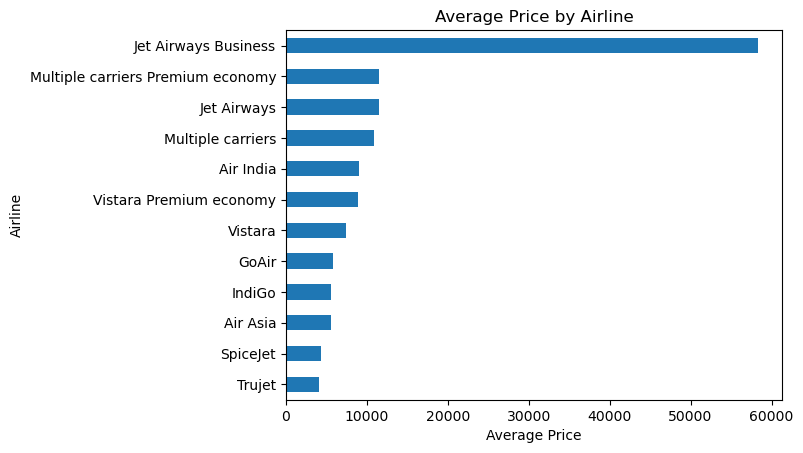

In [5]:
# Which airline has the highest average price?

df.groupby("Airline")["Price"].mean().sort_values().plot(kind="barh")

plt.xlabel("Average Price")
plt.ylabel("Airline")
plt.title("Average Price by Airline")
plt.show()

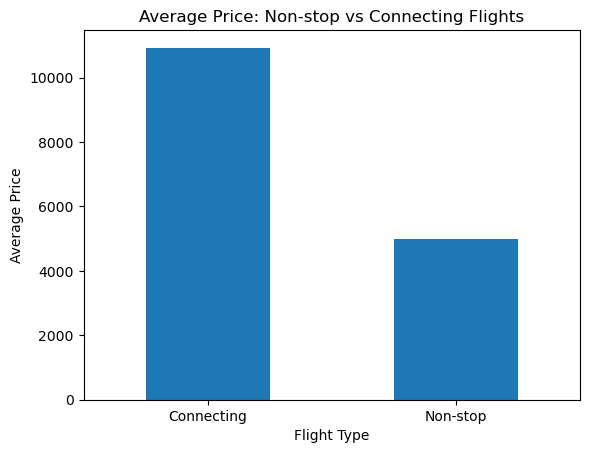

In [7]:
# Non-stop vs connecting flight prices?

df["Flight_Type"] = df["Total_Stops"].apply(
    lambda x: "Non-stop" if x == 0 else "Connecting")

df.groupby("Flight_Type")["Price"].mean().plot(kind="bar")

plt.xlabel("Flight Type")
plt.ylabel("Average Price")
plt.title("Average Price: Non-stop vs Connecting Flights")
plt.xticks(rotation=0)
plt.show()

In [8]:
# Which routes are expensive?

route_price = df.groupby(["Source", "Destination"])["Price"].mean().sort_values(ascending=False)
print(route_price.head(10))

Source    Destination
Delhi     Cochin         10355.756618
Kolkata   Banglore        8730.769265
Banglore  Delhi           7625.042649
Chennai   Kolkata         4789.892388
Mumbai    Hyderabad       4600.385307
Name: Price, dtype: float64


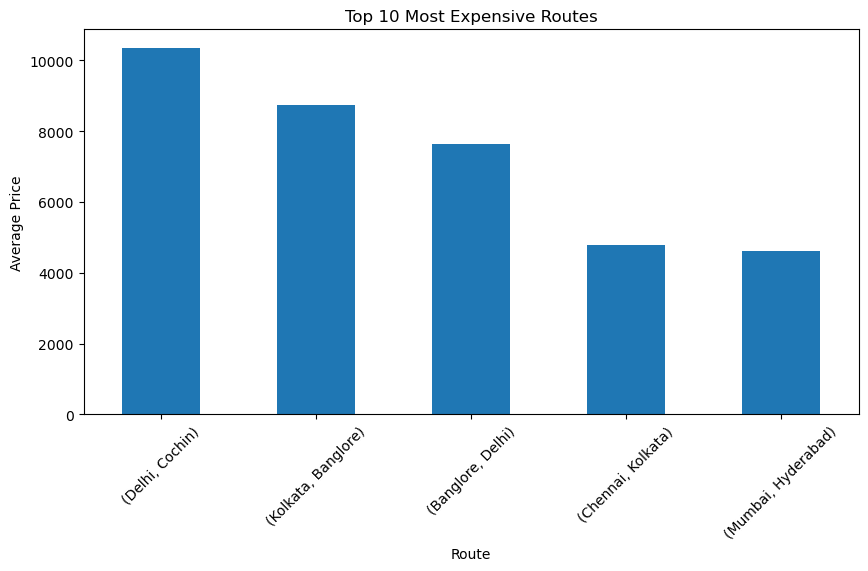

In [9]:
route_price.head(10).plot(kind="bar", figsize=(10,5))

plt.xlabel("Route")
plt.ylabel("Average Price")
plt.title("Top 10 Most Expensive Routes")
plt.xticks(rotation=45)
plt.show()

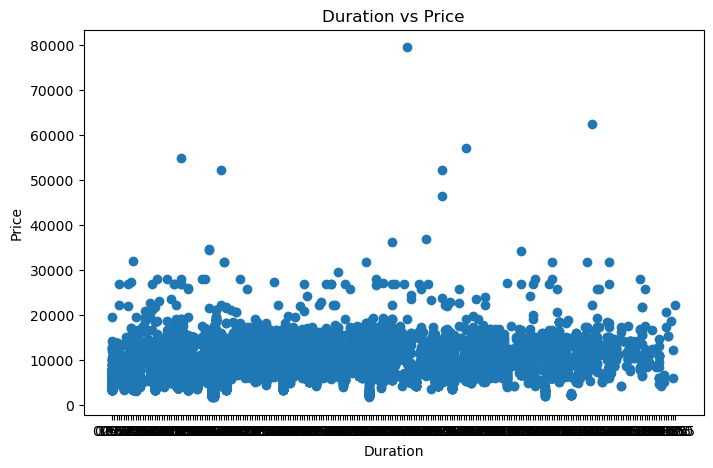

In [10]:
# Does duration affect price?

plt.figure(figsize=(8,5))

plt.scatter(df["Duration"], df["Price"])

plt.xlabel("Duration")
plt.ylabel("Price")
plt.title("Duration vs Price")

plt.show()

In [11]:
# Which departure times have higher prices?

df["Dep_Hour"] = pd.to_datetime(df["Dep_Time"]).dt.hour

C:\Users\bhoom\AppData\Local\Temp\ipykernel_3028\1513038268.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dep_Hour"] = pd.to_datetime(df["Dep_Time"]).dt.hour


In [12]:
# avg price

departure_price = df.groupby("Dep_Hour")["Price"].mean()
print(departure_price)

Dep_Hour
0      7308.578947
1      4354.621622
2      7909.376471
3     10474.625000
4      6707.235714
5      9148.839827
6      7773.089041
7      8302.660330
8      9720.050081
9      9081.195946
10     8695.959759
11     9139.742857
12     8511.330827
13     8729.398964
14     9855.329167
15     7466.405316
16     9629.000000
17     7965.705323
18    10013.859259
19     8137.142857
20     9562.837209
21     8195.672489
22     7670.026596
23     8165.272727
Name: Price, dtype: float64


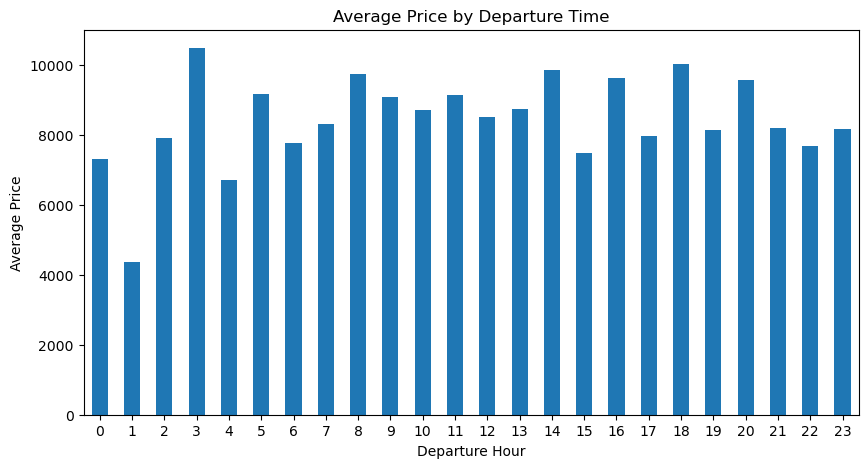

In [13]:
departure_price.plot(kind="bar", figsize=(10,5))

plt.xlabel("Departure Hour")
plt.ylabel("Average Price")
plt.title("Average Price by Departure Time")
plt.xticks(rotation=0)
plt.show()

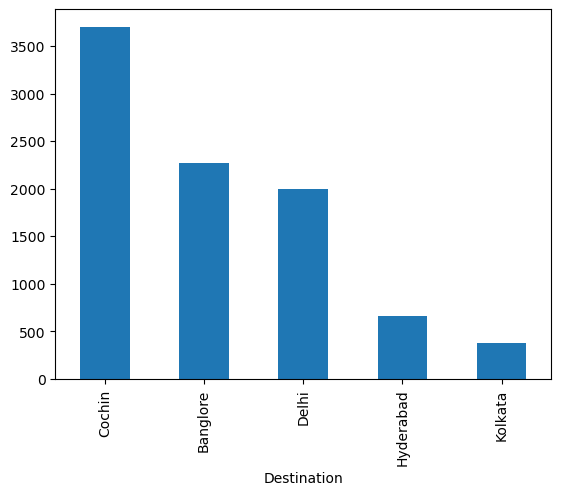

In [15]:
# Flights by destination

df["Destination"].value_counts().plot(kind="bar")
plt.show()